# Lab 1 - Classification with K-nearest neighbors

## M1DS - Machine Learning 1

### Instructions

1. Rename your notebook with your surnames as `lab1_Name1_Name2.ipynb`, and include your names in the notebook.

2. Your code, and its output, must be commented !

3. Please upload your notebook on Moodle in the dedicated section before the deadline.

<div style="background-color: rgba(255, 210, 0, 0.25); padding: 8px;">
Report written by Rami El Hage and Clément Martin, 11 September 2025.
</div>

In [1]:
# Importing usual libraries
import numpy as np
from matplotlib import pyplot as plt

In this lab, we are going to use one of the most famous datasets in machine learning : the *Iris* dataset (so famous that it has a Wikipedia page, see [here](https://en.wikipedia.org/wiki/Iris_flower_data_set)).

In [2]:
from sklearn.datasets import load_iris

# Loading the dataset
dataset = load_iris()

In [3]:
dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

The variable *dataset* has a dictionary-like structure. Let's take a look at the keys :

In [4]:
dataset['data'].shape

(150, 4)

You should play around and check what the dataset contains (using the syntax `dataset['key']`).

In [5]:
dataset['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

**Q1**. What is this dataset about ? How many examples do we have ? How many features ? What does 0, 1, or 2 mean for the target variable ?

In [6]:
#checking the number of exaples
dataset['target'].size

150

In [7]:
#checking the number of features
len(dataset['feature_names'])

4

In [8]:
#classes
dataset['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

<div style="background-color: rgba(255, 210, 0, 0.25); padding: 8px;">
----- This data set is about Iris flowers. We have 150 example of flowers. We have 4 features. Class 0 is for 'setosa', class 1 is for 'versicolor' and class 2 is for 'verginica' -----
</div>

**Q2.** Store the feature matrix in the variable X, and the target matrix in the variable y.

In [9]:
##########
y = dataset['target']
X = dataset['data']
##########

**Q3.** Check whether there are some missing data in the dataset (both in X and y). You might want to use `np.isnan` (see the documentation [here](https://numpy.org/doc/stable/reference/generated/numpy.isnan.html)).

In [61]:
##########
(True not in np.isnan(X)) and (True not in np.isnan(y))
##########

True

**Q4.** For now, we are going to use KNN with $K = 3$. We are going to use the `scikit-learn` implementation, see the documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html).
* Divide the dataset into a training set and a test set (80/20 split), setting `random_state` to 0 ;
* Train the model on the training set ;
* What is the accuracy of the model on the test set ?
* Display the confusion matrix (use `ConfusionMatrixDisplay`, with label names), and interpret it.

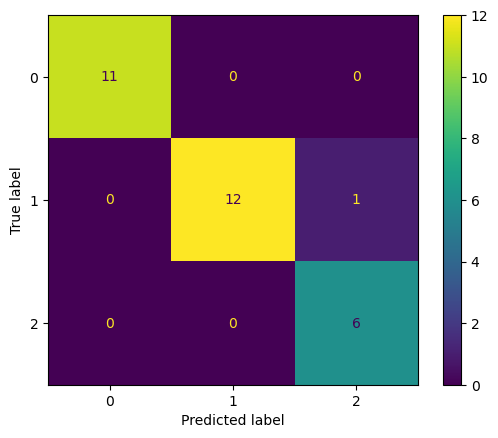

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

##########
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)
model = KNeighborsClassifier(3)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
accuracy_score(y_test,y_pred)
conf_matrix = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(conf_matrix)
disp.plot()
##########

In [73]:
X_train,X_test,y_train,y_test

(array([[6.2, 2.8, 4.8, 1.8],
        [5.1, 3.3, 1.7, 0.5],
        [5.6, 2.9, 3.6, 1.3],
        [7.7, 3.8, 6.7, 2.2],
        [5.4, 3. , 4.5, 1.5],
        [5.8, 4. , 1.2, 0.2],
        [6.4, 2.8, 5.6, 2.2],
        [6.1, 3. , 4.6, 1.4],
        [5.5, 2.3, 4. , 1.3],
        [6.9, 3.1, 5.1, 2.3],
        [6. , 2.9, 4.5, 1.5],
        [6.2, 2.9, 4.3, 1.3],
        [6.8, 3.2, 5.9, 2.3],
        [5. , 2.3, 3.3, 1. ],
        [4.8, 3.4, 1.6, 0.2],
        [6.1, 2.6, 5.6, 1.4],
        [5.2, 3.4, 1.4, 0.2],
        [6.7, 3.1, 4.4, 1.4],
        [5.1, 3.5, 1.4, 0.2],
        [5.2, 3.5, 1.5, 0.2],
        [5.5, 3.5, 1.3, 0.2],
        [4.9, 2.5, 4.5, 1.7],
        [6.2, 3.4, 5.4, 2.3],
        [7.9, 3.8, 6.4, 2. ],
        [5.4, 3.4, 1.7, 0.2],
        [6.7, 3.1, 5.6, 2.4],
        [6.3, 3.4, 5.6, 2.4],
        [7.6, 3. , 6.6, 2.1],
        [6. , 2.2, 5. , 1.5],
        [4.3, 3. , 1.1, 0.1],
        [4.8, 3.1, 1.6, 0.2],
        [5.8, 2.7, 5.1, 1.9],
        [5.7, 2.8, 4.1, 1.3],
        [5

<div style="background-color: rgba(255, 210, 0, 0.25); padding: 8px;">
----- Your answer here -----
</div>

**Q5.** Evaluate now the performance (in terms of accuracy) of this model using a 5-fold cross-validation.

In [25]:
from sklearn.model_selection import KFold

##########
kf = KFold(5)
accurate = 0
for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {i}:")
    y_pred = model.predict(X[test_index,:])
    fold_accurate = accuracy_score(y[test_index],y_pred)
    accurate += fold_accurate
    print(fold_accurate)

print(accurate/5)
##########

Fold 0:
1.0
Fold 1:
1.0
Fold 2:
0.8666666666666667
Fold 3:
0.9333333333333333
Fold 4:
0.9666666666666667
0.9533333333333334


**Q6.** Now vary the value of $K$ between 1 and 50, and conclude as to which value gives the best performance.

In [30]:
##########
for k in range(1,51):
    Kmodel = KNeighborsClassifier(k)
    Kmodel.fit(X_train,y_train)
    accurate = 0
    for i, (train_index, test_index) in enumerate(kf.split(X)):
        y_pred = Kmodel.predict(X[test_index,:])
        fold_accurate = accuracy_score(y[test_index],y_pred)
        accurate += fold_accurate
    print(accurate/5)
    
    
##########

1.0
0.9733333333333334
0.9533333333333334
0.96
0.9533333333333334
0.9666666666666666
0.9733333333333334
0.9733333333333334
0.9666666666666668
0.9733333333333334
0.9666666666666668
0.9800000000000001
0.9666666666666668
0.9800000000000001
0.9666666666666668
0.9733333333333334
0.9666666666666668
0.9666666666666668
0.9600000000000002
0.9600000000000002
0.9600000000000002
0.9600000000000002
0.9533333333333334
0.9600000000000002
0.9533333333333334
0.9400000000000001
0.9400000000000001
0.9466666666666667
0.9466666666666667
0.9533333333333334
0.9400000000000001
0.9333333333333333
0.9333333333333333
0.9533333333333334
0.9400000000000001
0.9400000000000001
0.9400000000000001
0.9400000000000001
0.9400000000000001
0.9400000000000001
0.9333333333333333
0.9333333333333333
0.9333333333333333
0.9333333333333333
0.9333333333333333
0.9333333333333333
0.9333333333333333
0.9266666666666667
0.9333333333333333
0.9333333333333333


<div style="background-color: rgba(255, 210, 0, 0.25); padding: 8px;">
----- Your answer here -----
</div>

<div style="background-color: rgba(0, 255, 0, 0.15); padding: 8px;">
    
<b>Important note</b> : what you just implemented is a cross-validation for model selection (i.e., picking a value for the hyperparameter $K$).

In a real-world scenario, where we would need to report the final performance of the model, things would be slightly more complicated :

<ul>
  <li>Set aside 20% of the dataset as the test set. This test set will only be used once at the very end of the process, and not during cross-validation !</li>
  <li>Use the remaining 80% to perform cross-validation and select the best value for $K$ (exactly as in Q6). This means that each fold uses 64% of the original dataset for training and 16% for validating.</li>
  <li>Once the best value for $K$ has been set, retrain the model on the whole 80%</li>
  <li>Finally, evaluate and report the performance of the model on the previously held-out 20% test set.</li>
</ul> 

</div>

**Q7.** What other hyperparameter(s) of the KNN method could we set ?

<div style="background-color: rgba(255, 210, 0, 0.25); padding: 8px;">
-----  We could set a different distance metrics or the power parameter for the Minkowski metric-----
</div>

**Q8.** KNN can be extended to a *weighted* variant. What do you think it means ?

<div style="background-color: rgba(255, 210, 0, 0.25); padding: 8px;">
----- It means that closer points of the query point has a greater influence on the weight -----
</div>

**Q9.** For d varying from 1 to 100, draw 101 points uniformly at random in the unit hypercube of dimension $d$. Then, for each value of d, compute the average Euclidian distance between the first point and the other 100.

Which phenomenon are we illustrating ? What does this mean for KNN ?

In [ ]:
##########
### YOUR CODE HERE
##########

<div style="background-color: rgba(255, 210, 0, 0.25); padding: 8px;">
----- Your answer here -----
</div>

---

End of lab1.